# Kourtesis Dimitris - Data Analysis - Set 5 

# Εκτιμητές

1:

Θέλουμε να εκτιμήσουμε τις παραμέτρους ενός πληθυσμού που ακολουθεί μια τυποποιημένη κανονική κατανομή. Πραγματοποιείστε $10^{5}$ πειράματα/μετρήσεις φτιάχνοντας τυχαία δείγματα $\mathbf{X}=\left(Χ_{1}, Χ_{2}, \ldots Χ_{n}\right)$, επιλέγοντας τιμές από τον αρχικό πληθυσμό.

Για τους κάτωθι εκτιμητές:
$$
\begin{aligned}
M & =\frac{1}{n} \sum_{i=1}^{n} X_{i} \\
S^{2} & =\frac{1}{n} \sum_{i=1}^{n}\left(X_{i}-M\right)^{2} \\
S^{* 2} & =\frac{1}{n-1} \sum_{i=1}^{n}\left(X_{i}-M\right)^{2}
\end{aligned}
$$
να δημιουργείστε τις κατανομές τους από τα πειράματα που θα πραγματοποιήσετε μεταβάλλοντας το μέγεθος n (πχ. για $\mathrm{n}=5,10, \ldots$ ) των δειγμάτων σας. Σχολιάσετε τα αποτελέσματα και αν αποτελούν συνεπείς και αμερόληπτους εκτιμητές των παραμέτρων μ και $σ^{2}$ του πληθυσμού.
'Σώστε' τα διάφορα ιστογράμματα και το κώδικα που χρησιμοποιήσατε.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

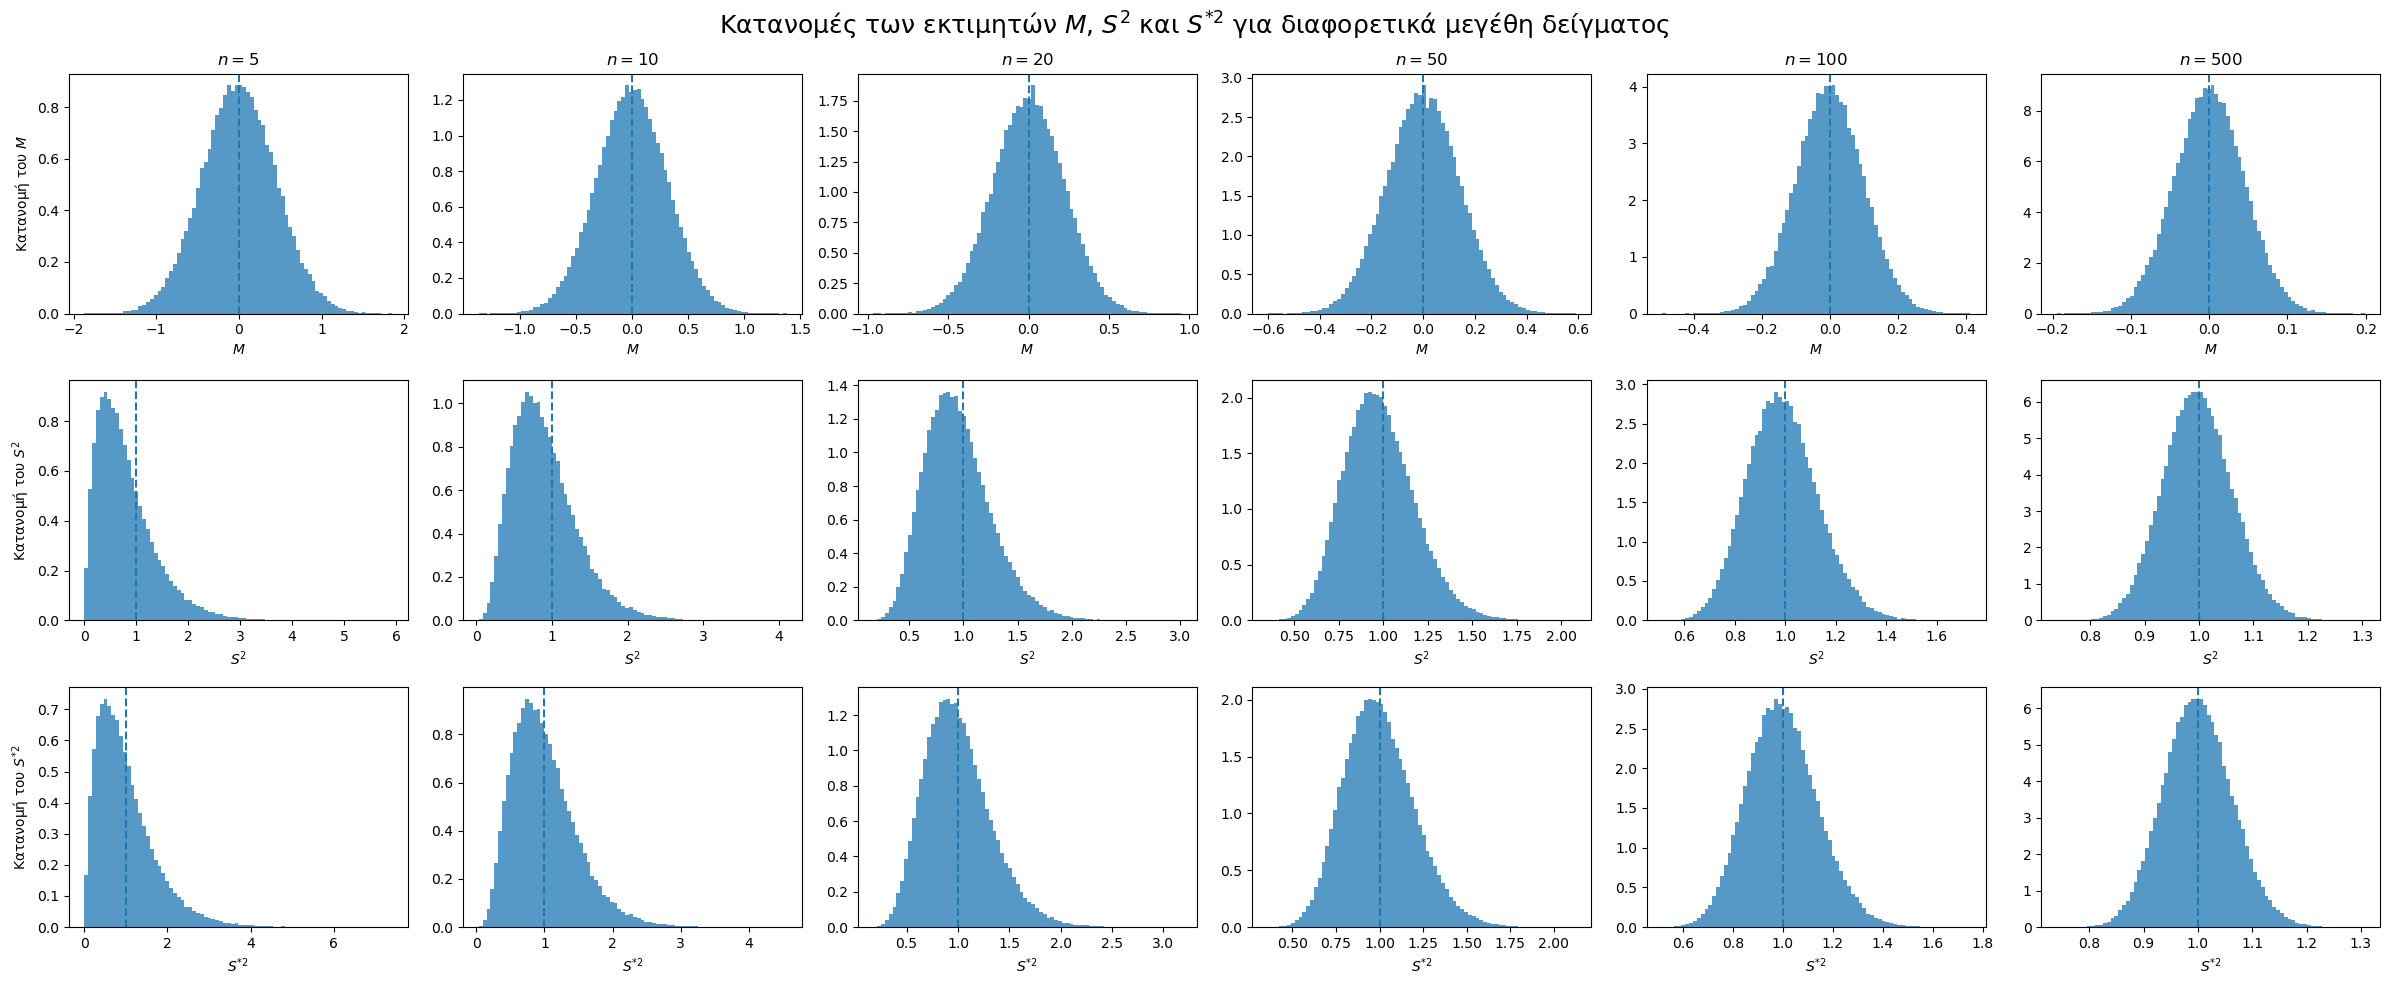

     n  E[M] αριθμητικά  Var(M) αριθμητικά  E[S²] αριθμητικά  Θεωρητικό E[S²]  \
0    5          0.00015            0.19927           0.80009            0.800   
1   10          0.00126            0.09958           0.89998            0.900   
2   20          0.00021            0.04941           0.94906            0.950   
3   50          0.00017            0.01992           0.97902            0.980   
4  100         -0.00016            0.00995           0.98983            0.990   
5  500          0.00019            0.00200           0.99779            0.998   

   E[S*²] αριθμητικά  Θεωρητικό E[S*²]  
0            1.00011                 1  
1            0.99998                 1  
2            0.99901                 1  
3            0.99900                 1  
4            0.99983                 1  
5            0.99979                 1  


In [2]:
# -----------------------------
# Ρυθμίσεις
# -----------------------------
N_exp = 10**5
n_values = [5, 10, 20, 50, 100, 500]

mu = 0
sigma = 1

rng = np.random.default_rng(seed=123)

results = []

# -----------------------------
# Δημιουργία σχήματος 3 x 6
# -----------------------------
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(n_values),
    figsize=(24, 10)
)

for col, n in enumerate(n_values):

    # Τυχαία δείγματα από Ν(0,1)
    X = rng.normal(loc=mu, scale=sigma, size=(N_exp, n))

    # Εκτιμητές
    M = np.mean(X, axis=1)

    S2 = np.mean((X - M[:, None])**2, axis=1)

    S2_star = np.sum((X - M[:, None])**2, axis=1) / (n - 1)

    # Αποθήκευση αριθμητικών αποτελεσμάτων
    results.append({
        "n": n,
        "E[M] αριθμητικά": np.mean(M),
        "Var(M) αριθμητικά": np.var(M),
        "E[S²] αριθμητικά": np.mean(S2),
        "Θεωρητικό E[S²]": (n - 1) / n,
        "E[S*²] αριθμητικά": np.mean(S2_star),
        "Θεωρητικό E[S*²]": 1
    })

    # -----------------------------
    # 1η γραμμή: M
    # -----------------------------
    ax = axes[0, col]
    ax.hist(M, bins=80, density=True, alpha=0.75)
    ax.axvline(mu, linestyle="--")
    ax.set_title(rf"$n={n}$")
    ax.set_xlabel(r"$M$")
    if col == 0:
        ax.set_ylabel(r"Κατανομή του $M$")

    # -----------------------------
    # 2η γραμμή: S²
    # -----------------------------
    ax = axes[1, col]
    ax.hist(S2, bins=80, density=True, alpha=0.75)
    ax.axvline(sigma**2, linestyle="--")
    ax.set_xlabel(r"$S^2$")
    if col == 0:
        ax.set_ylabel(r"Κατανομή του $S^2$")

    # -----------------------------
    # 3η γραμμή: S*²
    # -----------------------------
    ax = axes[2, col]
    ax.hist(S2_star, bins=80, density=True, alpha=0.75)
    ax.axvline(sigma**2, linestyle="--")
    ax.set_xlabel(r"$S^{*2}$")
    if col == 0:
        ax.set_ylabel(r"Κατανομή του $S^{*2}$")

fig.suptitle(
    r"Κατανομές των εκτιμητών $M$, $S^2$ και $S^{*2}$ για διαφορετικά μεγέθη δείγματος",
    fontsize=18
)

plt.tight_layout()
plt.savefig("estimators_histograms_3x6.png", dpi=300)
plt.show()

# -----------------------------
# Πίνακας αποτελεσμάτων
# -----------------------------
df = pd.DataFrame(results)

# Για πιο ευανάγνωστη εμφάνιση
df_rounded = df.round(5)

print(df_rounded)

## Σχολιασμός αποτελεσμάτων

Ο αρχικός πληθυσμός ακολουθεί την τυποποιημένη κανονική κατανομή, δηλαδή

$$
X \sim N(0,1),
$$

οπότε οι πραγματικές παράμετροι είναι

$$
\mu = 0, \qquad \sigma^2 = 1.
$$

### Εκτιμητής $M$

Ο εκτιμητής

$$
M = \frac{1}{n}\sum_{i=1}^{n}X_i
$$

εκτιμά τη μέση τιμή $\mu$ του πληθυσμού.

Από τα ιστογράμματα παρατηρούμε ότι η κατανομή του $M$ είναι κεντραρισμένη γύρω από το $0$, για όλες τις τιμές του $n$. Αυτό συμφωνεί με τη θεωρητική σχέση

$$
E[M] = \mu = 0.
$$

Άρα ο $M$ είναι αμερόληπτος εκτιμητής της μέσης τιμής.

Επίσης, καθώς το $n$ αυξάνεται, η κατανομή του $M$ γίνεται όλο και πιο στενή γύρω από το $0$. Αυτό συμβαίνει επειδή

$$
\operatorname{Var}(M)=\frac{\sigma^2}{n}.
$$

Επομένως, για $n \to \infty$,

$$
\operatorname{Var}(M) \to 0.
$$

Άρα ο $M$ είναι και συνεπής εκτιμητής της $\mu$.

---

### Εκτιμητής $S^2$

Ο εκτιμητής

$$
S^2 = \frac{1}{n}\sum_{i=1}^{n}(X_i-M)^2
$$

εκτιμά τη διασπορά του πληθυσμού.

Από τα αριθμητικά αποτελέσματα βλέπουμε ότι η μέση τιμή του $S^2$ είναι μικρότερη από την πραγματική τιμή

$$
\sigma^2 = 1.
$$

Θεωρητικά ισχύει

$$
E[S^2] = \frac{n-1}{n}\sigma^2.
$$

Άρα ο $S^2$ είναι μεροληπτικός εκτιμητής της διασποράς, επειδή υποεκτιμά συστηματικά το $\sigma^2$.

Ωστόσο, καθώς το $n$ αυξάνεται,

$$
\frac{n-1}{n} \to 1.
$$

Επομένως η μεροληψία του $S^2$ μειώνεται για μεγάλα δείγματα. Από τα ιστογράμματα φαίνεται ότι η κατανομή του συγκεντρώνεται όλο και περισσότερο γύρω από το $1$. Άρα, παρότι δεν είναι αμερόληπτος, ο $S^2$ είναι συνεπής εκτιμητής της διασποράς.

---

### Εκτιμητής $S^{*2}$

Ο εκτιμητής

$$
S^{*2} = \frac{1}{n-1}\sum_{i=1}^{n}(X_i-M)^2
$$

είναι η διορθωμένη δειγματική διασπορά.

Από τα αριθμητικά αποτελέσματα παρατηρούμε ότι η μέση τιμή του είναι πολύ κοντά στο

$$
\sigma^2 = 1
$$

για όλες τις τιμές του $n$. Θεωρητικά ισχύει

$$
E[S^{*2}] = \sigma^2.
$$

Άρα ο $S^{*2}$ είναι αμερόληπτος εκτιμητής της διασποράς.

Επίσης, καθώς το μέγεθος του δείγματος αυξάνεται, η κατανομή του γίνεται πιο στενή γύρω από το $1$. Επομένως ο $S^{*2}$ είναι και συνεπής εκτιμητής της διασποράς.

---

### Συμπέρασμα

Συνολικά:

- Ο $M$ είναι αμερόληπτος και συνεπής εκτιμητής της μέσης τιμής $\mu$.
- Ο $S^2$ δεν είναι αμερόληπτος εκτιμητής της διασποράς, επειδή υποεκτιμά το $\sigma^2$.
- Ο $S^2$ είναι όμως συνεπής εκτιμητής, αφού η μεροληψία του εξαφανίζεται για μεγάλο $n$.
- Ο $S^{*2}$ είναι αμερόληπτος και συνεπής εκτιμητής της διασποράς $\sigma^2$.

## Γιατί ο αμερόληπτος εκτιμητής χρησιμοποιεί $n-1$ αντί για $n$;

Με μια πρώτη ματιά φαίνεται πιο φυσικό να διαιρούμε με το $n$, αφού έχουμε $n$ μετρήσεις. Πράγματι, αν γνωρίζαμε την πραγματική μέση τιμή $\mu$ του πληθυσμού, τότε η διασπορά θα μπορούσε να εκτιμηθεί ως

$$
\frac{1}{n}\sum_{i=1}^{n}(X_i-\mu)^2.
$$

Στην πράξη όμως το $\mu$ είναι άγνωστο και το αντικαθιστούμε από τον δειγματικό μέσο

$$
M=\frac{1}{n}\sum_{i=1}^{n}X_i.
$$

Αυτό δημιουργεί ένα μικρό πρόβλημα: το $M$ υπολογίζεται από τα ίδια τα δεδομένα και «προσαρμόζεται» σε αυτά. Έτσι, οι αποκλίσεις

$$
X_i-M
$$

τείνουν να είναι λίγο μικρότερες από τις αποκλίσεις που θα είχαμε από την πραγματική μέση τιμή $\mu$.

---

### Μια διαισθητική εικόνα

Ας υποθέσουμε ότι έχουμε μόνο δύο μετρήσεις:

$$
X_1,\quad X_2.
$$

Μόλις υπολογίσουμε το μέσο

$$
M=\frac{X_1+X_2}{2},
$$

οι δύο αποκλίσεις δεν μπορούν πλέον να μεταβάλλονται ανεξάρτητα. Αν γνωρίζουμε τη μία,

$$
X_1-M,
$$

η άλλη είναι αναγκαστικά

$$
X_2-M=-(X_1-M).
$$

Δηλαδή υπάρχει μόνο μία πραγματικά ανεξάρτητη πληροφορία για τη διασπορά.

Με άλλα λόγια, ένα κομμάτι της πληροφορίας «καταναλώθηκε» για να υπολογίσουμε τον μέσο όρο.

---

### Βαθμοί ελευθερίας

Γενικά, όταν έχουμε $n$ δεδομένα και υπολογίζουμε από αυτά τον μέσο όρο, οι αποκλίσεις ικανοποιούν πάντα τη σχέση

$$
\sum_{i=1}^{n}(X_i-M)=0.
$$

Αυτό σημαίνει ότι αν γνωρίζουμε τις πρώτες $n-1$ αποκλίσεις, η τελευταία καθορίζεται αυτόματα.

Άρα υπάρχουν μόνο $n-1$ ανεξάρτητες ποσότητες.

Λέμε ότι απομένουν $n-1$ βαθμοί ελευθερίας (*degrees of freedom*).

---

### Γιατί διορθώνουμε με $n-1$;

Αν διαιρέσουμε με $n$, η εκτιμώμενη διασπορά βγαίνει συστηματικά λίγο μικρότερη από την πραγματική, επειδή χρησιμοποιήσαμε ήδη τα δεδομένα για να βρούμε το $M$.

Η διαίρεση με $n-1$ λειτουργεί ως διορθωτικός παράγοντας που αντισταθμίζει αυτή την υποεκτίμηση.

Με άλλα λόγια:

- το $1/n$ θεωρεί λανθασμένα ότι διαθέτουμε $n$ ανεξάρτητες πληροφορίες για τη διασπορά,
- το $1/(n-1)$ αναγνωρίζει ότι μία πληροφορία χρησιμοποιήθηκε για την εκτίμηση του μέσου όρου,
- έτσι η μέση τιμή του εκτιμητή γίνεται ακριβώς ίση με την πραγματική διασπορά.

---

### Συνοπτικά

Ο λόγος που εμφανίζεται το $n-1$ δεν είναι κάποια «μαγική» μαθηματική διόρθωση. Προκύπτει επειδή:

1. Δεν γνωρίζουμε την πραγματική μέση τιμή $\mu$.
2. Την εκτιμούμε από το ίδιο το δείγμα.
3. Η εκτίμηση αυτή αφαιρεί έναν βαθμό ελευθερίας.
4. Για να αντισταθμιστεί η συστηματική υποεκτίμηση της διασποράς, διαιρούμε με $n-1$ αντί με $n$.

Αυτό είναι γνωστό ως **διόρθωση του Bessel (Bessel's correction)** και είναι ο λόγος που ο εκτιμητής

$$
S^{*2}=\frac{1}{n-1}\sum_{i=1}^{n}(X_i-M)^2
$$

είναι αμερόληπτος, ενώ ο

$$
S^2=\frac{1}{n}\sum_{i=1}^{n}(X_i-M)^2
$$

υποεκτιμά κατά μέσο όρο την πραγματική διασπορά του πληθυσμού.